===== 线性拟合结果 =====
拟合公式：V_H = 42.5504 * I_S + 0.3073
斜率 k = 42.5504 mV/mA
截距 b = 0.3073 mV
相关系数 R² = 0.999995
线性相关性：极好


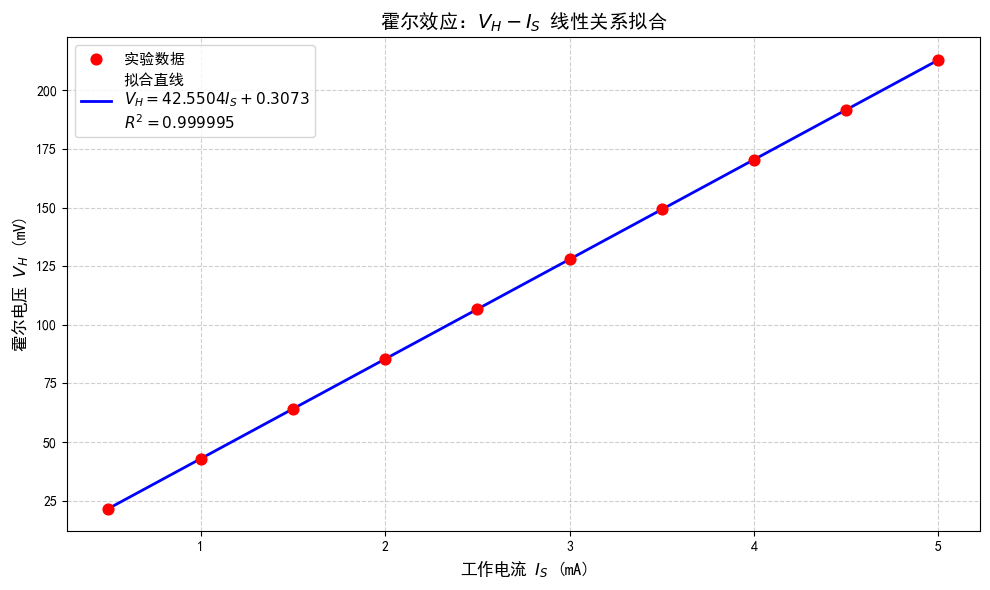

In [7]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# ===================== 1. 输入你的实验数据 =====================
Is = np.array([0.50, 1.00, 1.50, 2.00, 2.50, 3.00, 3.50, 4.00, 4.50, 5.00])  # mA
Vh = np.array([21.57, 42.75, 64.09, 85.55, 106.59, 128.07, 149.52, 170.42, 191.55, 213.1])  # mV

# ===================== 2. 线性拟合（最小二乘法） =====================
slope, intercept, r_value, p_value, std_err = stats.linregress(Is, Vh)

# 生成拟合直线
Vh_fit = slope * Is + intercept

# ===================== 3. 输出拟合结果 =====================
print("===== 线性拟合结果 =====")
print(f"拟合公式：V_H = {slope:.4f} * I_S + {intercept:.4f}")
print(f"斜率 k = {slope:.4f} mV/mA")
print(f"截距 b = {intercept:.4f} mV")
print(f"相关系数 R² = {r_value**2:.6f}")
print(f"线性相关性：{'极好' if r_value**2 > 0.999 else '良好'}")

# ===================== 4. 绘图可视化 =====================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
plt.rcParams['axes.unicode_minus'] = False     # 显示负号

plt.figure(figsize=(10, 6))

# 画实验数据点
plt.scatter(Is, Vh, color='red', s=60, label='实验数据', zorder=5)

# 画拟合直线
plt.plot(Is, Vh_fit, color='blue', linewidth=2, label=f'拟合直线\n$V_H = {slope:.4f}I_S + {intercept:.4f}$\n$R^2={r_value**2:.6f}$')

# 标签与标题
plt.xlabel('工作电流 $I_S$ (mA)', fontsize=12)
plt.ylabel('霍尔电压 $V_H$ (mV)', fontsize=12)
plt.title('霍尔效应：$V_H - I_S$ 线性关系拟合', fontsize=14, fontweight='bold')

plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('实验1.pdf', bbox_inches='tight')
plt.show()


【全数据拟合结果（包含1000mA异常点）】
拟合公式：V_H = 0.2469 * I_M + 3.5513 (mV)
斜率 k = 0.2469 mV/mA
截距 b = 3.5513 mV
相关系数 R² = 0.992613
------------------------------------------------------------
【线性区拟合结果（剔除1000mA异常点，100-900mA）】
拟合公式：V_H = 0.2599 * I_M + -1.2036 (mV)
斜率 k = 0.2599 mV/mA
截距 b = -1.2036 mV
相关系数 R² = 0.999893


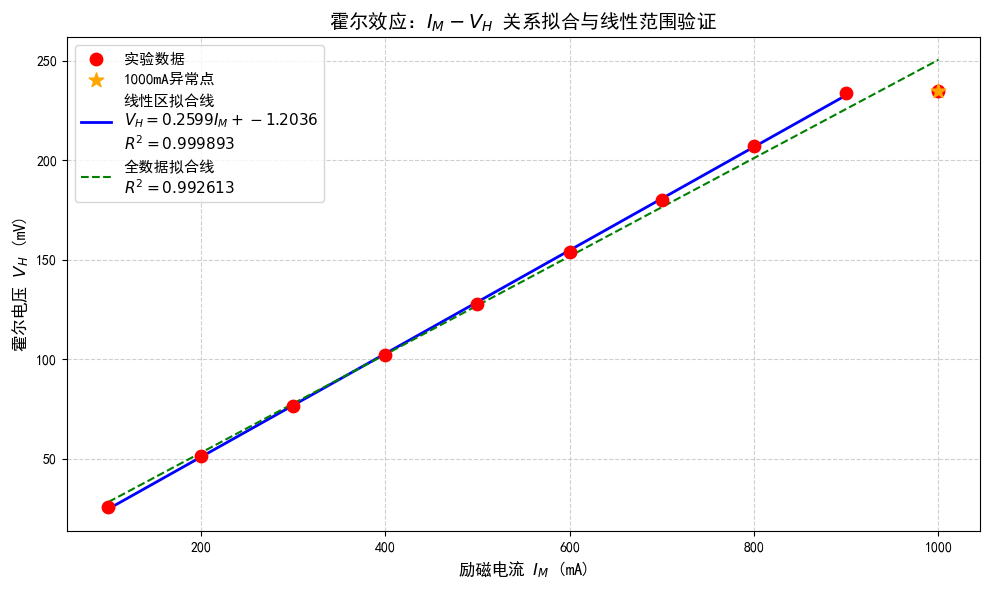


【思考题：I_M-V_H 直线斜率变化的原因分析】
1. 线性区（100-900mA）：
   铁芯未饱和，磁感应强度 B 与励磁电流 I_M 成正比（B ∝ I_M），
   根据霍尔效应公式 V_H = K_H I_S B，因此 V_H 与 I_M 呈严格线性关系，R²≈1。

2. 1000mA 点斜率突变原因：
   当励磁电流 I_M 增大到一定值后，电磁铁铁芯发生**磁饱和现象**：
   铁芯的磁感应强度 B 不再随 I_M 线性增长，而是趋于饱和，增长速率大幅下降。
   因此霍尔电压 V_H ∝ B，其增长速率也同步下降，导致 I_M-V_H 曲线斜率显著变小。

3. 补充说明：
   磁饱和是铁磁材料的固有特性，当外磁场足够大时，磁畴完全定向，
   磁导率 μ 急剧下降，B 不再线性增加，这是斜率变化的根本原因。


In [8]:
# ===================== 1. 输入你的实验数据 =====================
# 励磁电流 I_M (mA)
Im = np.array([100, 200, 300, 400, 500, 600, 700, 800, 900, 1000])
# 霍尔电压 V_H (mV)
Vh = np.array([25.69, 51.13, 76.65, 102.20, 127.90, 153.88, 180.17, 207.3, 233.7, 234.9])

# ===================== 2. 分两种情况拟合：全数据 & 剔除1000mA异常点 =====================
# 情况1：全数据拟合
slope_all, intercept_all, r_value_all, p_value_all, std_err_all = stats.linregress(Im, Vh)
Vh_fit_all = slope_all * Im + intercept_all

# 情况2：剔除1000mA异常点（前9个点）拟合线性区
Im_linear = Im[:-1]
Vh_linear = Vh[:-1]
slope_linear, intercept_linear, r_value_linear, p_value_linear, std_err_linear = stats.linregress(Im_linear, Vh_linear)
Vh_fit_linear = slope_linear * Im_linear + intercept_linear

# ===================== 3. 输出拟合结果 =====================
print("="*60)
print("【全数据拟合结果（包含1000mA异常点）】")
print(f"拟合公式：V_H = {slope_all:.4f} * I_M + {intercept_all:.4f} (mV)")
print(f"斜率 k = {slope_all:.4f} mV/mA")
print(f"截距 b = {intercept_all:.4f} mV")
print(f"相关系数 R² = {r_value_all**2:.6f}")
print("-"*60)
print("【线性区拟合结果（剔除1000mA异常点，100-900mA）】")
print(f"拟合公式：V_H = {slope_linear:.4f} * I_M + {intercept_linear:.4f} (mV)")
print(f"斜率 k = {slope_linear:.4f} mV/mA")
print(f"截距 b = {intercept_linear:.4f} mV")
print(f"相关系数 R² = {r_value_linear**2:.6f}")
print("="*60)

# ===================== 4. 绘图可视化 =====================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
plt.rcParams['axes.unicode_minus'] = False     # 显示负号
plt.figure(figsize=(10, 6))

# 1. 画所有实验数据点
plt.scatter(Im, Vh, color='red', s=80, label='实验数据', zorder=5)
# 标注1000mA异常点
plt.scatter(Im[-1], Vh[-1], color='orange', s=120, marker='*', label='1000mA异常点', zorder=6)

# 2. 画线性区拟合线（100-900mA）
plt.plot(Im_linear, Vh_fit_linear, color='blue', linewidth=2,
         label=f'线性区拟合线\n$V_H = {slope_linear:.4f}I_M + {intercept_linear:.4f}$\n$R^2={r_value_linear**2:.6f}$')

# 3. 画全数据拟合线（对比用）
plt.plot(Im, Vh_fit_all, color='green', linewidth=1.5, linestyle='--',
         label=f'全数据拟合线\n$R^2={r_value_all**2:.6f}$')

# 4. 图表美化
plt.xlabel('励磁电流 $I_M$ (mA)', fontsize=12)
plt.ylabel('霍尔电压 $V_H$ (mV)', fontsize=12)
plt.title('霍尔效应：$I_M-V_H$ 关系拟合与线性范围验证', fontsize=14, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig('实验2.pdf', bbox_inches='tight')
plt.show()

# ===================== 5. 思考题：斜率变化原因分析 =====================
print("\n" + "="*60)
print("【思考题：I_M-V_H 直线斜率变化的原因分析】")
print("1. 线性区（100-900mA）：")
print("   铁芯未饱和，磁感应强度 B 与励磁电流 I_M 成正比（B ∝ I_M），")
print("   根据霍尔效应公式 V_H = K_H I_S B，因此 V_H 与 I_M 呈严格线性关系，R²≈1。")
print("\n2. 1000mA 点斜率突变原因：")
print("   当励磁电流 I_M 增大到一定值后，电磁铁铁芯发生**磁饱和现象**：")
print("   铁芯的磁感应强度 B 不再随 I_M 线性增长，而是趋于饱和，增长速率大幅下降。")
print("   因此霍尔电压 V_H ∝ B，其增长速率也同步下降，导致 I_M-V_H 曲线斜率显著变小。")
print("\n3. 补充说明：")
print("   磁饱和是铁磁材料的固有特性，当外磁场足够大时，磁畴完全定向，")
print("   磁导率 μ 急剧下降，B 不再线性增加，这是斜率变化的根本原因。")
print("="*60)

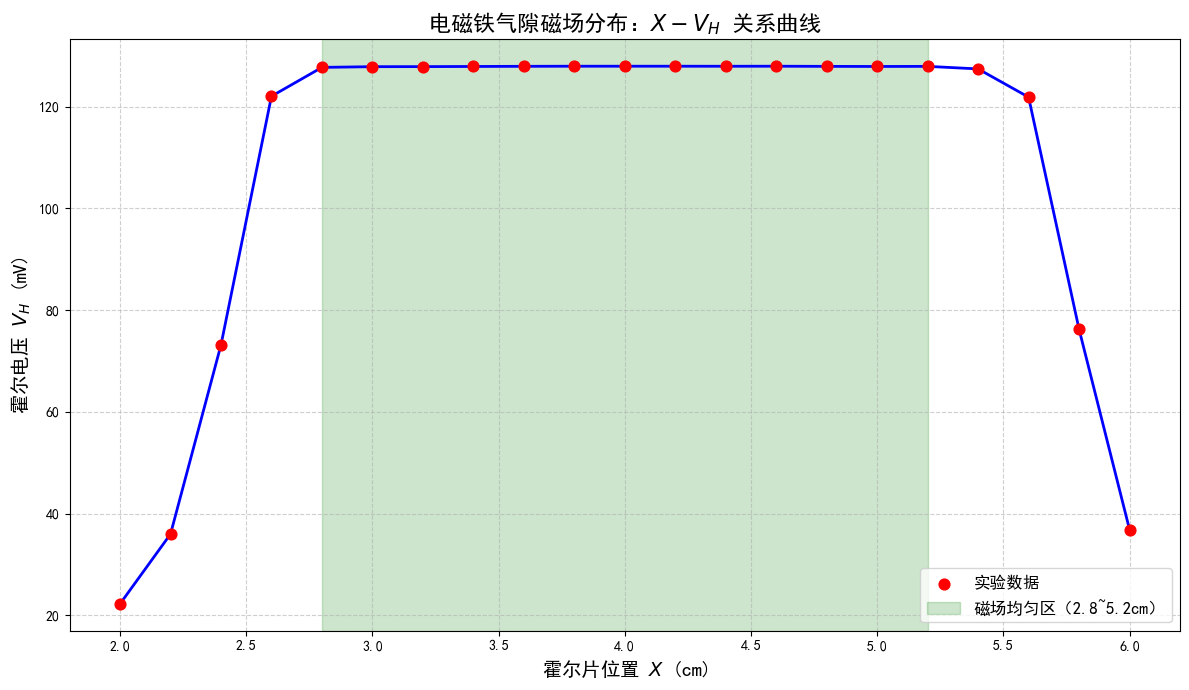

【思考题：X-V_H 曲线斜率变化的原因分析】

1. 曲线整体形态：
   曲线呈现典型的「马鞍形」分布：
   - 边缘区（X < 2.8cm、X > 5.2cm）：V_H 随 X 快速变化，斜率绝对值大
   - 中心均匀区（2.8cm ~ 5.2cm）：V_H 几乎保持恒定，斜率≈0，磁场高度均匀

2. 斜率变化的根本原因：
   霍尔电压 V_H ∝ 磁感应强度 B（V_H = K_H I_S B），因此 V_H 曲线直接反映气隙内 B 的分布：
   - 【边缘区（X < 2.8cm / X > 5.2cm）】：
     霍尔片位于电磁铁气隙的边缘，磁场存在严重的边缘效应（漏磁），
     磁感应强度 B 随位置快速变化，因此 V_H 随 X 快速上升/下降，斜率绝对值大。
   - 【中心均匀区（2.8cm ~ 5.2cm）】：
     霍尔片完全处于电磁铁气隙的中心区域，磁场被铁芯约束，漏磁极少，
     磁感应强度 B 几乎均匀恒定，因此 V_H 保持稳定，斜率≈0。

3. 补充说明：
   当 X 超过一定位置（>5.2cm）后，霍尔片逐渐移出气隙，磁场强度快速衰减，
   导致 V_H 急剧下降，曲线斜率由正变负，最终回到边缘的低磁场状态。


In [10]:
# ===================== 1. 输入你的实验数据 =====================
# 霍尔片位置 X (cm)
X = np.array([2.0, 2.2, 2.4, 2.6, 2.8, 3.0, 3.2, 3.4, 3.6, 3.8,
              4.0, 4.2, 4.4, 4.6, 4.8, 5.0, 5.2, 5.4, 5.6, 5.8, 6.0])
# 霍尔电压 V_H (mV)
Vh = np.array([22.25, 35.97, 73.16, 122.04, 127.71, 127.85, 127.86, 127.89,
               127.92, 127.94, 127.94, 127.94, 127.93, 127.94, 127.91, 127.89,
               127.91, 127.41, 121.86, 76.24, 36.86])

# ===================== 2. 划分区域：边缘上升区 / 均匀区 / 边缘下降区 =====================
# 均匀区范围：2.8cm ~ 5.2cm（V_H 基本稳定）
uniform_mask = (X >= 2.8) & (X <= 5.2)
# 边缘区：<2.8cm（上升沿）、>5.2cm（下降沿）
edge_mask = ~uniform_mask

# ===================== 3. 绘图可视化 =====================
plt.rcParams['font.sans-serif'] = ['SimHei']  # 显示中文
plt.rcParams['axes.unicode_minus'] = False     # 显示负号
plt.figure(figsize=(12, 7))

# 1. 画所有实验数据点
plt.scatter(X, Vh, color='red', s=60, label='实验数据', zorder=5)
# 画拟合曲线
plt.plot(X, Vh, color='blue', linewidth=2, zorder=4)

# 2. 标注均匀区
plt.axvspan(2.8, 5.2, alpha=0.2, color='green', label='磁场均匀区（2.8~5.2cm）')

# 3. 图表美化
plt.xlabel('霍尔片位置 $X$ (cm)', fontsize=14)
plt.ylabel('霍尔电压 $V_H$ (mV)', fontsize=14)
plt.title('电磁铁气隙磁场分布：$X-V_H$ 关系曲线', fontsize=16, fontweight='bold')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(fontsize=12)
plt.tight_layout()
plt.savefig('实验3.pdf', bbox_inches='tight')
plt.show()

# ===================== 4. 思考题：斜率变化原因分析 =====================
print("="*80)
print("【思考题：X-V_H 曲线斜率变化的原因分析】")
print("\n1. 曲线整体形态：")
print("   曲线呈现典型的「马鞍形」分布：")
print("   - 边缘区（X < 2.8cm、X > 5.2cm）：V_H 随 X 快速变化，斜率绝对值大")
print("   - 中心均匀区（2.8cm ~ 5.2cm）：V_H 几乎保持恒定，斜率≈0，磁场高度均匀")
print("\n2. 斜率变化的根本原因：")
print("   霍尔电压 V_H ∝ 磁感应强度 B（V_H = K_H I_S B），因此 V_H 曲线直接反映气隙内 B 的分布：")
print("   - 【边缘区（X < 2.8cm / X > 5.2cm）】：")
print("     霍尔片位于电磁铁气隙的边缘，磁场存在严重的边缘效应（漏磁），")
print("     磁感应强度 B 随位置快速变化，因此 V_H 随 X 快速上升/下降，斜率绝对值大。")
print("   - 【中心均匀区（2.8cm ~ 5.2cm）】：")
print("     霍尔片完全处于电磁铁气隙的中心区域，磁场被铁芯约束，漏磁极少，")
print("     磁感应强度 B 几乎均匀恒定，因此 V_H 保持稳定，斜率≈0。")
print("\n3. 补充说明：")
print("   当 X 超过一定位置（>5.2cm）后，霍尔片逐渐移出气隙，磁场强度快速衰减，")
print("   导致 V_H 急剧下降，曲线斜率由正变负，最终回到边缘的低磁场状态。")
print("="*80)